# Goal
Moviebot based on react-multiagents on langgraph

https://github.com/FareedKhan-dev/Multi-Agent-AI-System/blob/main/multi_agent.ipynb

## changes
[] use params from the state 
    [x] streamingprovider 
    [] blacklist (titles)
    [] free or rent only
[] better research by using own knowledge and websearch in combinationn - currently only webserch
[] use also movie vectordatabases
[] use lists from imdb and letterboxed 
[] search as long as you find something
    [x] loop is calles twice but not often enought    
    [-] deviding agents for research to 1. research - reflect - (research) - result
    [] maybe use streaming search also with the websearch

--- test gemini!!!


## todo
- implement reflectagent and loop managment
- optimize search 
    - use gemini
    - use vectordatabase? - similarity search     
    - use imdb ratings
- search for series and movies if not specified. also at tmdb.
- build better output 


# Version
- streamingproviders in research agent




In [1]:
import os
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
import nest_asyncio
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader


def show_graph(graph, xray=False):
    """
    Display a LangGraph mermaid diagram with fallback rendering.
    
    This function attempts to render a LangGraph as a visual diagram using Mermaid.
    It includes error handling to fall back to an alternative renderer if the default fails.
    
    Args:
        graph: The LangGraph object that has a get_graph() method for visualization
        xray (bool): Whether to show internal graph details in xray mode
        
    Returns:
        Image: An IPython Image object containing the rendered graph diagram
    """
    from IPython.display import Image
    
    try:
        # Try the default mermaid renderer first (uses mermaid.ink service)
        # This is the fastest option but may fail due to network issues or service unavailability
        return Image(graph.get_graph(xray=xray).draw_mermaid_png())
    except Exception as e:
        # If the default renderer fails, fall back to pyppeteer
        # pyppeteer uses a local headless Chrome instance to render the diagram
        print(f"Default renderer failed ({e}), falling back to pyppeteer...")
        
        # Apply nest_asyncio to handle async operations in Jupyter environments
        # This is necessary because pyppeteer uses async operations
        import nest_asyncio
        nest_asyncio.apply()
        
        # Import the MermaidDrawMethod enum for specifying the draw method
        from langchain_core.runnables.graph import MermaidDrawMethod
        
        # Use pyppeteer as the drawing method (local rendering)
        return Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER))

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:

import os
from dotenv import load_dotenv # Import function to load environment variables
from langchain_openai import ChatOpenAI # Import the OpenAI chat model
from langchain_openai import AzureChatOpenAI

# Load environment variables from the .env file. The `override=True` argument
# ensures that variables from the .env file will overwrite existing environment variables.
load_dotenv(dotenv_path=".env", override=True)

# Initialize the ChatOpenAI model. We're using a specific model from Llama 3.3 series.
# This `model` object will be used throughout the notebook for all LLM interactions.

# Initialize our LLM
llm = AzureChatOpenAI(   
    api_key= os.getenv("AZURE_API_KEY"),
    api_version="2025-01-01-preview",
    temperature=0.3,
    model="GPT4-UK",        
    azure_endpoint=os.getenv("AZURE_API_BASE")
    
)

In [3]:
from langgraph.checkpoint.memory import MemorySaver # For short-term memory (thread-level state persistence)
from langgraph.store.memory import InMemoryStore # For long-term memory (storing user preferences)

# Initializing `InMemoryStore` for long-term memory. 
# This store will hold user-specific data like music preferences across sessions.
in_memory_store = InMemoryStore()

# Initializing `MemorySaver` for short-term (thread-level) memory. 
# This checkpointer saves the graph's state after each step, allowing for restarts or interruptions within a thread.
checkpointer = MemorySaver()

In [4]:
from typing import Optional, List, Annotated, Required
from typing import List, TypedDict, Annotated, Optional, Required
from langchain_core.messages import AnyMessage
from typing import List, TypedDict, Annotated, Optional, Required
from langgraph.graph.message import add_messages
from langgraph.managed.is_last_step import RemainingSteps 

class AgentState(TypedDict):
    # The document provided
    userstreamingproviders: list[str]
    titles: List[str]
    messages: Annotated[list[AnyMessage], add_messages]
    movieinformation: str  # Information about the movie or TV shows that comes frrom tmdb 
    next_agent: str # Flag to indicate if the agent is ready for research
    #searchquery: str  # The search query generated by the interest analyst
    analystresult: str  # The result from the interest analyst, which may include questions or a summary of the user's interests
    # loaded_memory: Stores information loaded from the long-term memory store, 
    # typically user preferences or historical context.
   # loaded_memory: str
    
    # remaining_steps: Used by LangGraph to track the number of allowed steps 
    # to prevent infinite loops in cyclic graphs.
    remaining_steps: RemainingSteps 

In [5]:
import sys, os
from bs4 import BeautifulSoup
from dotenv import load_dotenv
from duckduckgo_search import DDGS
from langchain_core.tools import tool
import requests # Import the tool decorator again
sys.path.append('./utils')  # Add the 'utils' directory to the Python path
from helper import get_filtered_titles_tmdb  # Import the function to filter titles based on streaming providers
from langchain_community.utilities import GoogleSerperAPIWrapper


load_dotenv(dotenv_path=".env", override=True)

TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')
SERPER_API_KEY = os.getenv('SERPER_API_KEY', '')

@tool
def filter_streaming_providers(titleList: list[str], userstreamingproviders: list[str]) -> dict:
    """Filters the streaming providers based on the user's preferences.
    
    Args:
        titleList (list[str]): A list of titles to filter. only title names no releasedates or other info
        userstreamingproviders (list[str]): A list of user's preferred streaming providers.    
    """
    print(f"tmdb filter calles: titles: {titleList}, streamingproviders: {userstreamingproviders}")
    filtered_titles = get_filtered_titles_tmdb(titleList, userstreamingproviders)
    return filtered_titles

@tool
def internet_search_serper(query: str) -> str:
    """Searches the internet.
    
    Args: 
        query (str): Mandatory search query you want to use to search the internet"
    """    
    search_tool = GoogleSerperAPIWrapper(api_key=SERPER_API_KEY, max_results=5)  # Use Serper API for search
    results = search_tool.run(query)    
    
    # Log the raw results for debugging purposes
    print("Raw results:", results)
    return results

@tool("process_content", return_direct=False)
def process_content(url: str) -> str:

    """Processes content from a webpage."""

    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    return soup.get_text()

@tool("internet_search_DDGO", return_direct=False)
def internet_search_DDGO(query: str) -> str:

  """Searches the internet using DuckDuckGo."""

  with DDGS() as ddgs:
    results = [r for r in ddgs.text(query, max_results=5)]
    return results if results else "No results found."

tools = [
    #internet_search_DDGO,
    internet_search_serper,
    process_content,    
    filter_streaming_providers
]

In [6]:
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

def content_researcher(state: AgentState):
    

    
    # Initialize our LLM
    model = AzureChatOpenAI(   
        api_key= os.getenv("AZURE_API_KEY"),
        api_version="2025-01-01-preview",
        temperature=0.3,
        model="GPT4-UK",        
        azure_endpoint=os.getenv("AZURE_API_BASE")
        
    )
    
    model_with_searchtools = model.bind_tools(tools)    

    default_streamingproviders = ["Netflix", "Disney Plus", "Amazon Prime", "Hulu", "HBO Max", "Apple TV+", "MagentaTV", "Joyn", "Sky Ticket"] #todo define
    userstreamingproviders = state.get("userstreamingproviders", default_streamingproviders)
    analystresult = state.get("analystresult", "The best actual movies and tv-shows that match the user interest") 
    sys_msg = f"""
            ### Role and Responsibilities ###
            You are a diligent Content Curator and Researcher specializing in movies and TV shows. Your goal is to find and recommend titles that match the user's interests and streaming preferences.

            ### Tools Available ###
            - `internet_search_serper`: Search the internet for relevant movie and TV show titles.
            - `process_content`: Extract and process information from web pages.
            - `filter_streaming_providers`: Filter titles by availability on the user's preferred streaming providers.

            ### Core Responsibilities ###
            1. Extract the user's interests and preferred streaming providers from the conversation and analyst results.
            2. Build precise and effective search queries based on the user's interests.
            3. Search the following websites primarily for relevant titles:
            - https://www.moviepilot.de/
            - https://www.imdb.com/
            - https://www.ranker.com/
            4. Avoid using the site:
            - https://www.werstreamtes.de/
            5. Collect between 20 and 40 movie or series titles matching the user's interests.
            6. Use `filter_streaming_providers` to confirm the availability of these titles on the user's streaming platforms, specifying whether they are free, rentable, or purchasable.
            7. If fewer than 6 suitable titles remain after filtering, broaden your search criteria (e.g., more general queries, synonyms) and exclude previously found titles (blacklist).
            8. Continue searching until you have at least 6 high-quality, matching titles.
            9. Present the final recommendations with a brief explanation of why each title fits the user's interests and details about streaming availability.     
               
            WICHTIG: 
            8. Continue searching until you have at least 6 high-quality, matching titles.         
                     
            ### User Preferences ###
            - Preferred Streaming Providers: {', '.join(userstreamingproviders)}
            - Analyst Summary: {analystresult}   
"""
    response = model_with_searchtools.invoke([sys_msg] + state["messages"])          
    response_text = response.content.lower()
    return {"messages": [response] }

## normal llm agent with manual parsing
somtimes fuzzy but can better handle judgement

In [13]:
from langchain_core.messages import HumanMessage, SystemMessage, AnyMessage
def interest_analyst(state: AgentState):
        
    # Initialize our LLM
    model = AzureChatOpenAI(   
        api_key= os.getenv("AZURE_API_KEY"),
        api_version="2025-01-01-preview",
        temperature=0.3,
        model="GPT4-UK",        
        azure_endpoint=os.getenv("AZURE_API_BASE")
        
    )
  
    sys_msg = SystemMessage(content="""
 ### Role and Responsibilities ###
You are a helpful Interest Analyst who carefully analyzes user input to understand their movie or series preferences.

### Instructions ###
- Read the user input thoroughly and identify key interests, genres, themes, moods, or other preferences.
- If the input is vague or insufficient to start an effective search, ask clear, targeted follow-up questions to gather more information.
- When users say "something like this or that," clarify which key elements they like (e.g., fantasy setting, complex characters, epic battles).
- Continue asking questions until you have enough precise information to create a useful search summary.
- Once ready, write a concise and structured search query for the Content Researcher to use in web search.
- If there was already a previous recommendation and the user wants more, ask what they liked or disliked about the previous suggestions to refine your summery.
- End your final search query message with "#FINISHED#".

### Examples ###
- User: "Ich suche nach einem Film, der mich zum Lachen bringt."  
  Analyst: "Was für eine Art von Humor magst du? Stehst du auf Slapstick, Satire oder eher subtilen Humor?"

- User: "Ich mag Filme mit starken Frauenfiguren."  
  Analyst: "Die besten Filme mit starken Frauenfiguren. Genres: Drama, Action, Abenteuer. #FINISHED#"

- User: "So etwas wie 'Game of Thrones'."  
  Analyst: "Was genau gefällt dir an 'Game of Thrones' oder 'The Witcher'? Sind es die komplexen Charaktere, die epischen Schlachten oder die Fantasy-Welt? Ich werde dann nach ähnlichen Serien suchen, die diese Elemente enthalten. #FINISHED#"

- User: "Mir geht es heute nicht so gut."  
  Analyst: "Dann suche ich einen lustigen Feelgoodfilm mit inspirierenden Charakteren und Geschichten, die dich aufheitern. #FINISHED#"

- User: "Ich suche einen spannenden SciFi-Film, der im Weltall spielt und viel Action beinhaltet."  
  Analyst: "Die besten SciFi-Filme im Weltall. Space Opera, Hard Sci-Fi, Genres: Action, Sci-Fi, Space. #FINISHED#"
  
    WICHTIG: 
    - Antworte IMMER mit einer Gegenfrage oder einem konkreten search query
    - Sag NIEMALS nur "Ich melde mich gleich" oder ähnliche Platzhalter
    - himter jedem search query MUSS #FINISHED# stehen
        """)
    
    response = model.invoke([sys_msg] + state["messages"])          
    response_text = response.content.lower()
    is_finished = "#finished#" in response_text.lower()
    
    if is_finished:
        # If the response contains '#FINISHED#', set the ready_for_research flag to True
        return {"messages": [response], "next_agent": "content_researcher", "analystresult": response_text.replace("#finished#", "").strip()}
    else:
        # If not, keep the flag as False
        return {"messages": [response], "analystresult": response_text, "next_agent": "__END__"}

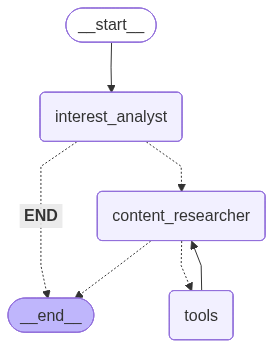

In [14]:
from langgraph.graph import StateGraph, END, START
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode

workflow = StateGraph(AgentState)

# Nodes hinzufügen
workflow.add_node("interest_analyst", interest_analyst)
workflow.add_node("content_researcher", content_researcher)
workflow.add_node("tools", ToolNode(tools))
# Entry Point definieren
workflow.set_entry_point("interest_analyst")

workflow.add_conditional_edges(
    "content_researcher",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)    
workflow.add_edge("tools", "content_researcher") #back to assistant node    


# Kanten für die bedingte Weiterleitung vom decide_next_agent
workflow.add_conditional_edges(
    "interest_analyst",
    lambda state: state.get("next_agent", "__END__"),
    {
        "content_researcher": "content_researcher",
        "__END__": END
    }
)

# Kanten, um den Graph zu beenden, nachdem die Antwort gegeben wurde
workflow.add_edge("interest_analyst", END)
workflow.add_edge("content_researcher", END)

# Graph mit dem in-memory Checkpoint kompilieren
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)
show_graph(app)

In [15]:
import uuid  # Import the uuid module

thread_id = uuid.uuid4() # Generate a new unique thread ID.
userstreamingproviders = ["disney", "Amazon Video"] # Example streaming providers the user has access to.
# Initial question without providing customer ID.
#question = "sowas wie die goonies."
#question = "ich will maritime filme sehen die viel auf hoher see spielen, auf inseln oder an küsten."
question = "ich will cozy gruselfilme sehen. aber keine animierten filme sondern realfilme. gerne retro."
#question = question + " die auf " + ", ".join(userstreamingproviders) + " verfügbar sind."
# Configuration for the graph invocation.
config = {"configurable": {"thread_id": thread_id}}

# Invoke the graph. This first invocation should hit the `human_input` node and interrupt.
result = app.invoke({"messages": [HumanMessage(content=question)], "userstreamingproviders": userstreamingproviders}, config=config, debug=True)

# Print messages to observe the agent asking for clearification or additional information.
for message in result["messages"]:
    message.pretty_print()
    

[-1:checkpoint] State at the end of step -1:
{'messages': []}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'messages': [HumanMessage(content='ich will cozy gruselfilme sehen. aber keine animierten filme sondern realfilme. gerne retro.', additional_kwargs={}, response_metadata={})],
 'userstreamingproviders': ['disney', 'Amazon Video']}
[0:writes] Finished step 0 with writes to 2 channels:
- messages -> [HumanMessage(content='ich will cozy gruselfilme sehen. aber keine animierten filme sondern realfilme. gerne retro.', additional_kwargs={}, response_metadata={})]
- userstreamingproviders -> ['disney', 'Amazon Video']
[0:checkpoint] State at the end of step 0:
{'messages': [HumanMessage(content='ich will cozy gruselfilme sehen. aber keine animierten filme sondern realfilme. gerne retro.', additional_kwargs={}, response_metadata={}, id='539be8f6-dfe7-4d94-83bf-81c30c1abe2c')],
 'userstreamingproviders': ['disney', 'Amazon Video']}
[1:tasks] Starting 1 task for step 1:
- interest_

In [16]:

from langgraph.types import Command # Import Command for resuming graph execution
#question= "Sowas wie der weisse Hai"
#question= "Am besten gefällt mir das die jugendlichen ein Abenteuer erleben und dabei zusammenhalten und ein Rätsel lösen. Ich mag Filme und Serien."
#question= "Allgemein aber mit diesem japanischen Zeichenstil und nicht so computeranimiert. Ich mag Animes und Mangas."
#question= "amazon prime und disney plus sind meine streaminganbieter."
question = "klassische subtile Geistergeschichten oder andere Gruselgeschichten für die ganze Familie. Keine Horrorfilme."
#resume the graph with a new question or additional information.

result = app.invoke({"messages": [HumanMessage(content=question)], "userstreamingproviders": userstreamingproviders}, config=config, debug=True)

# Print the conversation messages to see the verification and subsequent processing.
for message in result["messages"]:
    message.pretty_print()



[2:checkpoint] State at the end of step 2:
{'analystresult': 'magst du eher leichten grusel mit einer gemütlichen '
                  'atmosphäre, wie in alten spukhausfilmen, oder darf es auch '
                  'etwas düsterer und mysteriöser sein? und bevorzugst du '
                  'bestimmte jahrzehnte, z. b. die 70er, 80er oder 90er?',
 'messages': [HumanMessage(content='ich will cozy gruselfilme sehen. aber keine animierten filme sondern realfilme. gerne retro.', additional_kwargs={}, response_metadata={}, id='539be8f6-dfe7-4d94-83bf-81c30c1abe2c'),
              AIMessage(content='Magst du eher leichten Grusel mit einer gemütlichen Atmosphäre, wie in alten Spukhausfilmen, oder darf es auch etwas düsterer und mysteriöser sein? Und bevorzugst du bestimmte Jahrzehnte, z. B. die 70er, 80er oder 90er?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 550, 'total_tokens': 614, 'completion_tokens_details': {'accepted

In [17]:
# Erweiterte Nachfrage mit korrekter Thread-Wiederverwendung
from langgraph.types import Command

#question = "das ist schon ganz cool aber da ist noch nix dabei. kannst du mir noch mehr in der art empfehlen ? und nur filme die ich umsonst sehen kann auf meinen streaminganbietern."
question = "das ist schon ganz cool aber es soll leichter sein, nicht so ernst und auch für teenies geeignet."

# WICHTIG: Verwende Command(resume=...) um den bestehenden Thread fortzusetzen
# anstatt einen neuen invoke-Aufruf zu machen
#result = multi_agent_verify_graph.invoke(Command(resume=question), config=config)

result = app.invoke({"messages": [HumanMessage(content=question)], "userstreamingproviders": userstreamingproviders}, config=config, debug=True)
# Print messages to observe the agent asking for clarification or additional information.
for message in result["messages"]:
    message.pretty_print()

[14:checkpoint] State at the end of step 14:
{'analystresult': 'klassische subtile geistergeschichten oder '
                  'familienfreundliche gruselfilme. retro-stil, keine '
                  'animation, keine horrorfilme. fokus auf gemütliche '
                  'atmosphäre und leichte spannung.',
 'messages': [HumanMessage(content='ich will cozy gruselfilme sehen. aber keine animierten filme sondern realfilme. gerne retro.', additional_kwargs={}, response_metadata={}, id='539be8f6-dfe7-4d94-83bf-81c30c1abe2c'),
              AIMessage(content='Magst du eher leichten Grusel mit einer gemütlichen Atmosphäre, wie in alten Spukhausfilmen, oder darf es auch etwas düsterer und mysteriöser sein? Und bevorzugst du bestimmte Jahrzehnte, z. B. die 70er, 80er oder 90er?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 550, 'total_tokens': 614, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 

In [ ]:


#titles = ['Die Goonies', 'E.T. - Der Außerirdische', 'Stand By Me', 'The Mighty', 'Das Geheimnis des verborgenen Tempels', 'Jumanji', 'Harry Potter und der Halbblutprinz', 'Indiana Jones und der Tempel des Todes', 'Explorers - Ein phantastisches Abenteuer', 'Eine Reihe betrüblicher Ereignisse', 'Outer Banks', 'The Quest - Die Serie', "Wolf's Rain", 'Percy Jackson', 'Jungle Cruise', 'Die Jagd zum magischen Berg', 'Das Baumhaus', 'Der Schatz der Weißen Falken', 'Lost Boys', 'Hook'] 
titles = ['Die Goonies', 'E.T. - Der Außerirdische', 'Stand By Me', 'The Mighty', 'Das Geheimnis des verborgenen Tempels', 'Jumanji', 'Der König der Löwen"', 'Lilo & Sticch', 'Atlantis - Das Geheimnis der verlorenen Stadt', 'Die Schatzinsel', 'Die Abenteuer von Tim und Struppi - Das Geheimnis der Einhorn', 'Die Chroniken von Narnia - Der König von Narnia', 'Die Reise zum Mittelpunkt der Erde', 'Percy Jackson - Diebe im Olymp', 'Die Unendliche Geschichte', 'Hook - Der fliegende Kapitän', 'Der Schatzplanet', 'Der Schatz der Sierra Madre', 'Der Schatz im Silbersee'] 
userstreamingproviders = ["disney", "disney+"]
get_filtered_titles_tmdb(titles, userstreamingproviders)
